In [9]:
import pandas as pd
import os
import re

In [10]:
print("=== 1단계: 데이터 불러오기 및 병합 ===")
# 게임별 장르 매핑
game_meta = {
    "Elden_Ring": "RPG", "Witcher_3": "RPG", "Cyberpunk_2077": "RPG",
    "PUBG": "FPS", "CS2": "FPS", "R6_Siege": "FPS"
}

df_list = []
for file in os.listdir("data"):
    if file.endswith("_reviews.csv"):
        game_name = file.replace("_reviews.csv", "")
        temp_df = pd.read_csv(f"data/{file}")
        temp_df['Game_Name'] = game_name
        temp_df['Genre'] = game_meta.get(game_name, "Unknown")
        df_list.append(temp_df)

=== 1단계: 데이터 불러오기 및 병합 ===


In [11]:
# 하나로 병합
df = pd.concat(df_list, ignore_index=True)
print(f"병합 직후 데이터 크기: {df.shape}")

병합 직후 데이터 크기: (19842, 7)


In [12]:
print("\n=== 2단계: 데이터 정제 (결측치, 중복값, 타입 처리) ===")
df.dropna(subset=['review'], inplace=True)
df.drop_duplicates(subset=['review'], keep='first', inplace=True)
df['voted_up'] = df['voted_up'].astype(int) # True/False를 1/0으로 변환
print(f"정제 후 남은 데이터 크기: {df.shape}")



=== 2단계: 데이터 정제 (결측치, 중복값, 타입 처리) ===
정제 후 남은 데이터 크기: (10056, 7)


In [13]:
print("\n=== 3단계: 자연어 처리(NLP) 및 파생 변수 생성 ===")
def clean_text(text):
    text = str(text).lower() # 소문자 변환
    text = re.sub(r'[^a-z\s]', '', text) # 특수문자 제거
    text = re.sub(r'\s+', ' ', text).strip() # 다중 공백 압축
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))

# 의미 없는 짧은 리뷰(단어 3개 미만) 필터링
df = df[df['review_length'] >= 3]
print(f"최종 전처리 완료 데이터 크기: {df.shape}")


=== 3단계: 자연어 처리(NLP) 및 파생 변수 생성 ===
최종 전처리 완료 데이터 크기: (7842, 7)


In [14]:
print("\n=== 4단계: 전처리 완료 데이터 백업 저장 ===")
df.to_csv("data/preprocessed_reviews.csv", index=False, encoding="utf-8-sig")
print("성공적으로 'preprocessed_reviews.csv' 파일이 저장되었습니다!")

# 결과 미리보기 (출력)
display(df[['Game_Name', 'Genre', 'voted_up', 'review_length', 'clean_review']].head())


=== 4단계: 전처리 완료 데이터 백업 저장 ===
성공적으로 'preprocessed_reviews.csv' 파일이 저장되었습니다!


,Game_Name,Genre,voted_up,review_length,clean_review
0,CS2,FPS,1,36,i like counterstrike because its a competitive...
2,CS2,FPS,1,9,tgis game is super gooood plaze no vac cheat
3,CS2,FPS,1,119,theres a secret that gives players no peace wh...
4,CS2,FPS,1,3,gold gold gold
5,CS2,FPS,1,7,worst game ever only better than lol


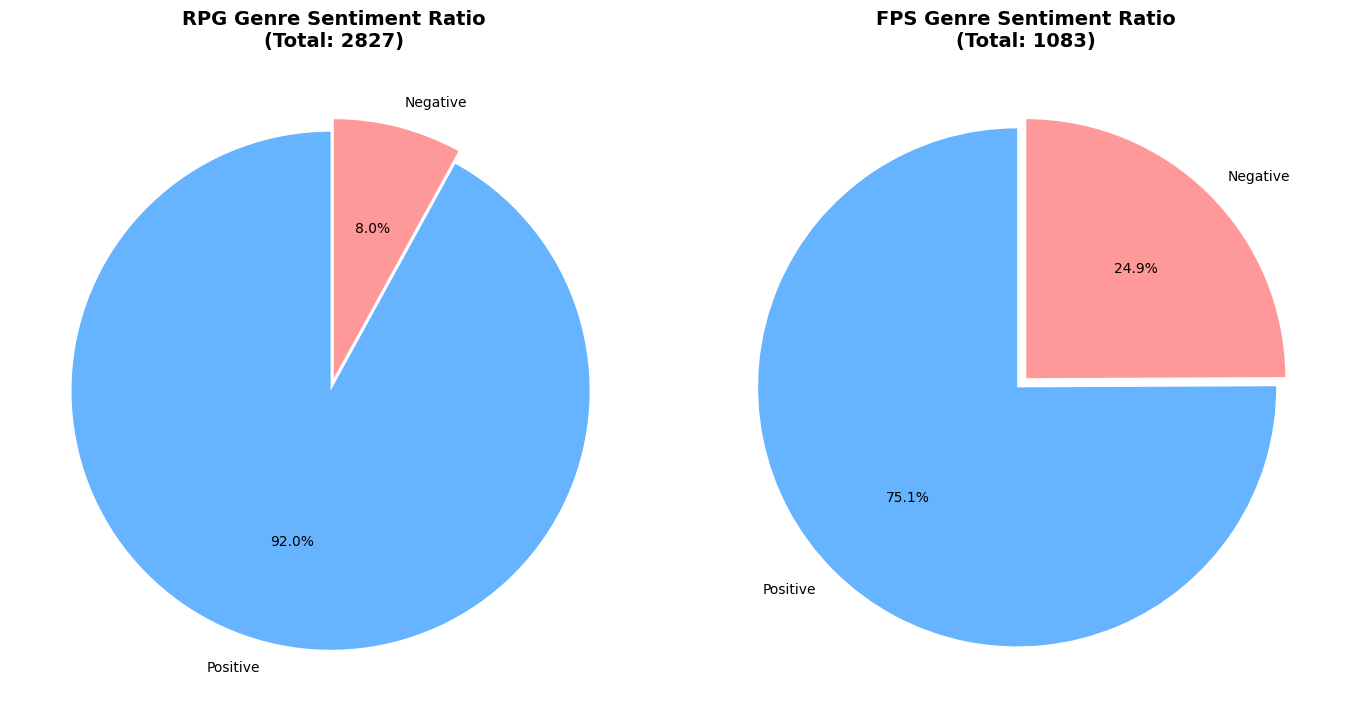

In [27]:
import matplotlib.pyplot as plt

# 1. 장르별 긍정(1)/부정(0) 개수를 직접 계산
rpg_pos = len(df[(df['Genre'] == 'RPG') & (df['voted_up'] == 1)])
rpg_neg = len(df[(df['Genre'] == 'RPG') & (df['voted_up'] == 0)])
rpg_stats = [rpg_pos, rpg_neg]

fps_pos = len(df[(df['Genre'] == 'FPS') & (df['voted_up'] == 1)])
fps_neg = len(df[(df['Genre'] == 'FPS') & (df['voted_up'] == 0)])
fps_stats = [fps_pos, fps_neg]

# 2. 도화지 준비 (가로 14, 세로 7 크기)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# 3. RPG 파이 차트 그리기
ax1.pie(rpg_stats, labels=['Positive', 'Negative'], autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff','#ff9999'], explode=(0.05, 0))
ax1.set_title(f'RPG Genre Sentiment Ratio\n(Total: {rpg_pos+rpg_neg})', fontsize=14, fontweight='bold')

# 4. FPS 파이 차트 그리기
ax2.pie(fps_stats, labels=['Positive', 'Negative'], autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff','#ff9999'], explode=(0.05, 0))
ax2.set_title(f'FPS Genre Sentiment Ratio\n(Total: {fps_pos+fps_neg})', fontsize=14, fontweight='bold')

# 5. 그래프 한 번에 출력하기 (반드시 같은 셀 안에 있어야 함!)
plt.tight_layout()
plt.show()

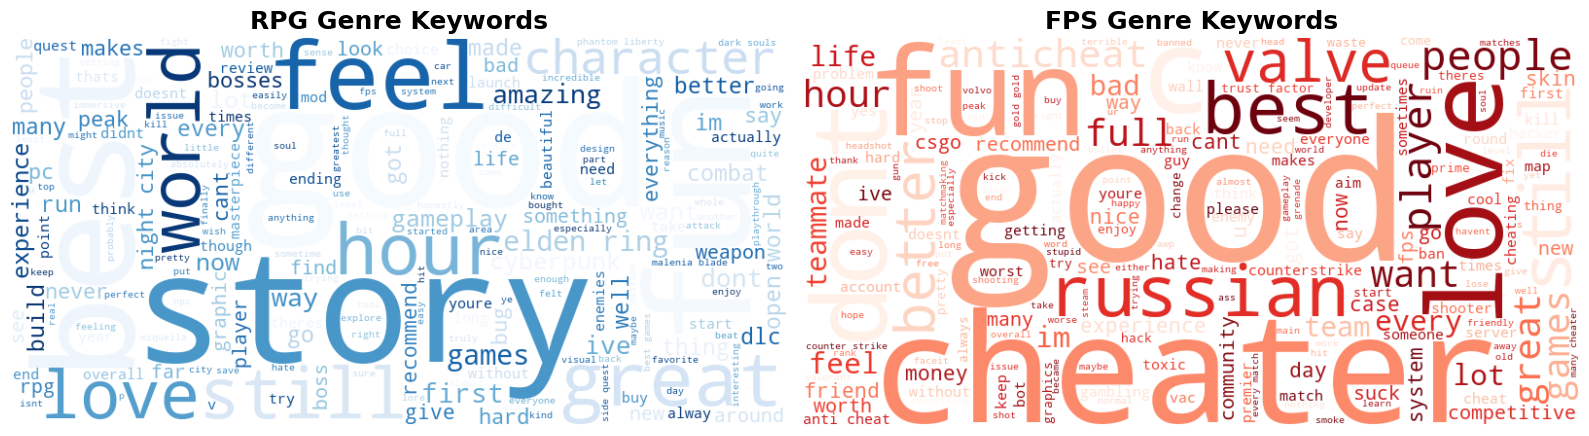

In [29]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. 불용어(Stopwords) 커스텀 설정
# 'game', 'play' 같은 단어는 게임 리뷰에 무조건 등장하므로 분석의 핵심을 가립니다. 이를 제외해 줍니다.
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['game', 'play', 'played', 'playing', 'even', 'one', 'really', 'make', 'time', 'much', 'will', 'get'])

# 2. 장르별로 텍스트 하나로 뭉치기 (전처리된 clean_review 사용)
rpg_text = " ".join(df[df['Genre'] == 'RPG']['clean_review'].astype(str))
fps_text = " ".join(df[df['Genre'] == 'FPS']['clean_review'].astype(str))

# 3. 워드클라우드 이미지 생성 (RPG는 파란색 톤, FPS는 빨간색 톤으로 차별화)
wordcloud_rpg = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=custom_stopwords, colormap='Blues').generate(rpg_text)

wordcloud_fps = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=custom_stopwords, colormap='Reds').generate(fps_text)

# 4. 도화지 준비 (가로 16, 세로 8 크기로 큼직하게)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# RPG 영역 (왼쪽)
ax1.imshow(wordcloud_rpg, interpolation='bilinear')
ax1.axis('off') # 지저분한 테두리와 눈금선 숨기기
ax1.set_title('RPG Genre Keywords', fontsize=18, fontweight='bold')

# FPS 영역 (오른쪽)
ax2.imshow(wordcloud_fps, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('FPS Genre Keywords', fontsize=18, fontweight='bold')

# 5. 한 지붕 아래에서 깔끔하게 출력
plt.tight_layout()
plt.show()

In [30]:
%pip install torch torchvision scikit-learn

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---- ----------------------------------- 12.8/114.6 MB 61.7 MB/s eta 0:00:02
   --------- ------------------------------ 26.5/114.6 MB 62.3 MB/s eta 0:00:02
   ------------- -------------------------- 39.1/114.6 MB 61.8 MB/s eta 0:00:02
   ------------------ --------------------- 52.7/114.6 MB 61.9 MB/s eta 0:00:01
   ----------------------- ---------------- 66.1/114.6 MB 62.0 MB/s eta 0:00:01
   --------------------------- ------------ 79.4/114.6 MB 62.1 MB/s eta 0:00:01
   -------------------------------- ------- 92.5/114.6 MB 62.2 MB/s eta 0:00:01
   ------------------------------------ -- 105.9/114.6 MB 62.2 MB/s eta 0:00:01
   --------------------------------------  114.3/114.6 MB 62.1 MB/s eta 0:00:01
   ---------------------------------------- 114.6/114.6 MB 56.6 MB/s  0:00:02
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 29.9 MB


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

print("=== 1단계: 단어 사전(Vocabulary) 구축 ===")
# 모든 리뷰의 단어를 모아서 고유한 번호를 부여합니다.
vocab = {"<PAD>": 0, "<UNK>": 1} # 0: 빈칸 채움용, 1: 모르는 단어용
word_idx = 2

for review in df['clean_review']:
    for word in str(review).split():
        if word not in vocab:
            vocab[word] = word_idx
            word_idx += 1

print(f"완성된 총 단어 개수(Vocab Size): {len(vocab)}개")

print("\n=== 2단계: 텍스트를 숫자로 변환하고 길이 맞추기 ===")
MAX_LEN = 50 # 하나의 리뷰당 최대 50단어까지만 사용 (넘으면 자르고, 모자라면 0으로 채움)

def text_to_tensor(text):
    tokens = str(text).split()
    # 단어를 번호로 바꾸되, 사전에 없으면 <UNK>(1)로 처리
    seq = [vocab.get(word, 1) for word in tokens]
    
    # 50단어로 길이 맞추기 (Padding)
    if len(seq) > MAX_LEN:
        seq = seq[:MAX_LEN]
    else:
        seq = seq + [0] * (MAX_LEN - len(seq))
    return seq

# 전체 데이터 변환
X = np.array([text_to_tensor(text) for text in df['clean_review']])
y = np.array(df['voted_up'].values)

print("\n=== 3단계: 학습용(Train) / 테스트용(Test) 데이터 분리 ===")
# 전체 데이터를 8:2 비율로 무작위 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n=== 4단계: PyTorch Dataset & DataLoader 생성 ===")
class SteamReviewDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X_data = torch.LongTensor(X_data)
        self.y_data = torch.FloatTensor(y_data) # 이진 분류(0 or 1)이므로 Float 사용
        
    def __len__(self):
        return len(self.X_data)
    
    def __getitem__(self, idx):
        return self.X_data[idx], self.y_data[idx]

train_dataset = SteamReviewDataset(X_train, y_train)
test_dataset = SteamReviewDataset(X_test, y_test)

# 미니 배치 사이즈 64로 설정하여 데이터로더 장전
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"테스트 데이터 개수: {len(test_dataset)}")

# 로더가 잘 작동하는지 첫 번째 배치 뽑아서 확인
sample_X, sample_y = next(iter(train_loader))
print(f"배치 X(입력) 형태: {sample_X.shape} -> (배치 크기, 최대 단어 수)")
print(f"배치 y(정답) 형태: {sample_y.shape} -> (배치 크기)")